# Linear Regression and Multiple Linear Regression in Python


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Simple Linear Regression

Simple Linear Regression uses **one independent variable (X)** to predict **one dependent variable (y)**.

Example:
- X = Study Hours
- y = Marks


In [2]:
# Independent variable: Study Hours
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)

# Dependent variable: Marks
y = np.array([40, 50, 50, 60, 70])


In [3]:
print("Study Hours:")
print(X)

print("\nMarks:")
print(y)


Study Hours:
[[1]
 [2]
 [3]
 [4]
 [5]]

Marks:
[40 50 50 60 70]


### 3. Create and Train the Simple Linear Regression Model

In [4]:
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.16]


### 4. Display Intercept and Slope

In [5]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


Intercept: 33.0
Slope: 7.0


### 5. Predict Marks for New Data

In [6]:
# Predict marks for a student who studies for 6 hours
new_data = np.array([[6]])

predicted_marks = model.predict(new_data)

print("Predicted Marks:", predicted_marks[0])


Predicted Marks: 75.0


### 6. Predict the Original Observations

In [7]:
y_pred = model.predict(X)

print("Predicted values:")
print(y_pred)


Predicted values:
[40. 47. 54. 61. 68.]


### 7. Visualize the Regression Line

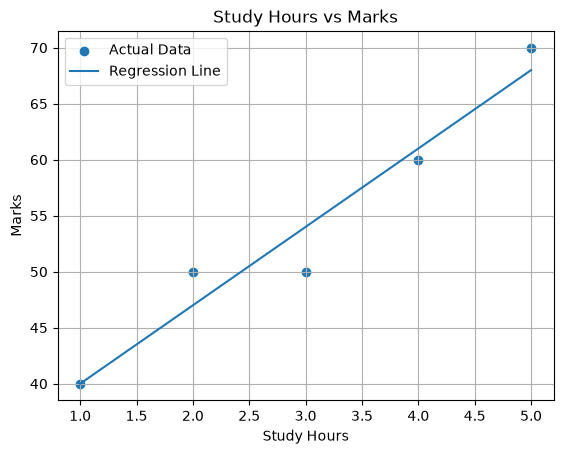

In [8]:
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, label="Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.legend()
plt.grid(True)
plt.show()


## 8. Evaluate the Simple Linear Regression Model

In [9]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 2.0
MSE: 6.0
RMSE: 2.449489742783178
R2: 0.9423076923076923


## 9. Simple Linear Regression Using Train-Test Split



In [10]:
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Marks": [32, 38, 43, 50, 54, 61, 68, 73, 81, 88]
}

df = pd.DataFrame(data)
df


,Study_Hours,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


### 10. Separate Input and Output Variables

In [11]:
X = df[["Study_Hours"]]
y = df["Marks"]


### 11. Split the Dataset into Training and Testing Data

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### 12. Train the Model Using Training Data

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


Intercept: 24.724137931034484
Slope: 6.163793103448276


### 13. Predict Test Data

In [14]:
y_pred = model.predict(X_test)

print("Actual values:", y_test.to_numpy())
print("Predicted values:", y_pred)


Actual values: [81 38]
Predicted values: [80.19827586 37.05172414]


### 14. Evaluate the Test Data

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.875
MSE: 0.7709943519619504
RMSE: 0.8780628405541089
R2: 0.9983320836085193


### 15. Actual vs Predicted Values

In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})

comparison


,Actual,Predicted
0,81,80.198276
1,38,37.051724


### 16. Actual vs Predicted Plot

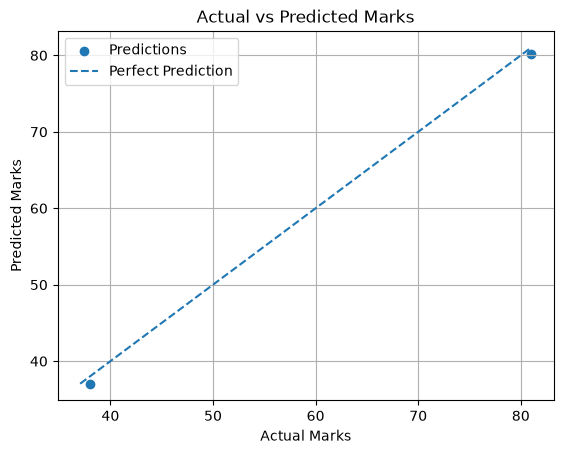

In [17]:
plt.scatter(y_test, y_pred, label="Predictions")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.legend()
plt.grid(True)
plt.show()


### 17. Residual Plot

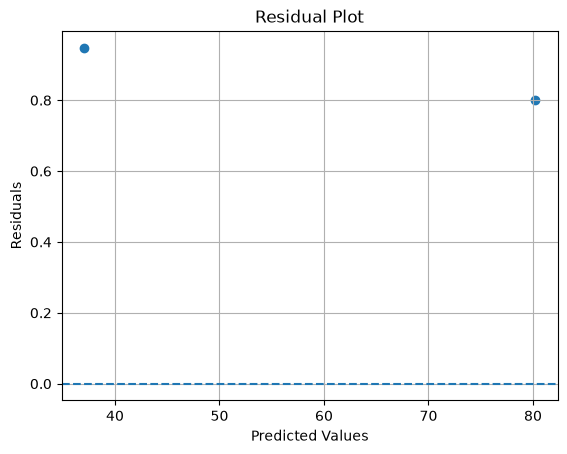

In [18]:
residuals = y_test.to_numpy() - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


## 18. Multiple Linear Regression

Multiple Linear Regression uses **more than one independent variable** to predict one dependent variable.

Example:
- Study Hours
- Attendance
- Assignment Score

are used to predict:
- Final Marks


In [19]:
data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95],
    "Assignment_Score": [50, 55, 58, 65, 70, 74, 80, 88],
    "Final_Marks": [42, 48, 54, 61, 67, 73, 81, 89]
}

multi_df = pd.DataFrame(data)
multi_df


,Study_Hours,Attendance,Assignment_Score,Final_Marks
0,2,60,50,42
1,3,65,55,48
2,4,70,58,54
3,5,75,65,61
4,6,80,70,67
5,7,85,74,73
6,8,90,80,81
7,9,95,88,89


### 19. Define Features and Target

In [20]:
X = multi_df[["Study_Hours", "Attendance", "Assignment_Score"]]
y = multi_df["Final_Marks"]


### 20. Train-Test Split for Multiple Linear Regression

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### 21. Train the Multiple Linear Regression Model

In [22]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

print("Intercept:", multi_model.intercept_)


Intercept: -29.244102564102562


### 22. Display Feature Coefficients

In [23]:
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multi_model.coef_
})

coefficient_table


,Feature,Coefficient
0,Study_Hours,0.146923
1,Attendance,0.734615
2,Assignment_Score,0.533333


### 23. Predict Test Data

In [24]:
multi_y_pred = multi_model.predict(X_test)

comparison_multi = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": multi_y_pred
})

comparison_multi


,Actual,Predicted
0,48,48.280000
1,73,73.693333


### 24. Evaluate Multiple Linear Regression

In [25]:
mae = mean_absolute_error(y_test, multi_y_pred)
mse = mean_squared_error(y_test, multi_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, multi_y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.4866666666666717
MSE: 0.27955555555556205
RMSE: 0.5287301349039621
R2: 0.9982108444444444


### 25. Predict Final Marks for a New Student

In [26]:
new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [82],
    "Assignment_Score": [72]
})

prediction = multi_model.predict(new_student)

print("Predicted Final Marks:", prediction[0])


Predicted Final Marks: 70.27589743589745


### 26. Actual vs Predicted Plot for Multiple Linear Regression

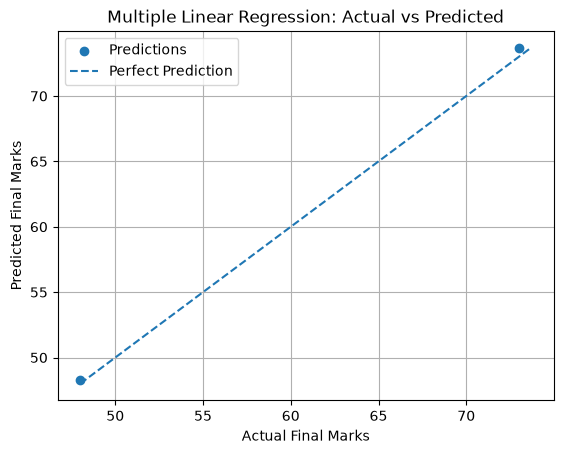

In [27]:
plt.scatter(y_test, multi_y_pred, label="Predictions")

minimum = min(y_test.min(), multi_y_pred.min())
maximum = max(y_test.max(), multi_y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


### 27. Residual Plot for Multiple Linear Regression

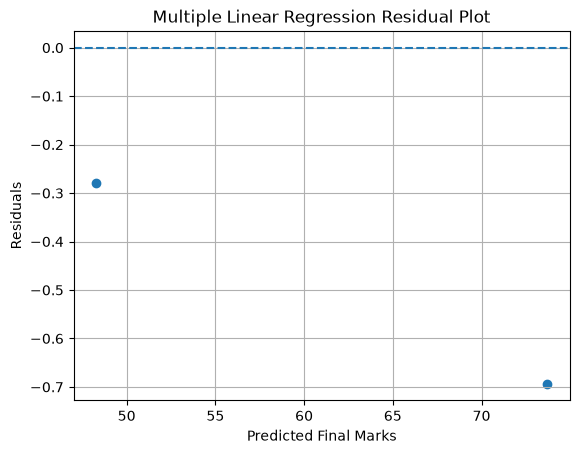

In [28]:
multi_residuals = y_test.to_numpy() - multi_y_pred

plt.scatter(multi_y_pred, multi_residuals)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Final Marks")
plt.ylabel("Residuals")
plt.title("Multiple Linear Regression Residual Plot")
plt.grid(True)
plt.show()


## 28. Categorical Data Encoding

Machine-learning models require numerical input. Therefore, a categorical feature such as **Location** must be converted into numerical form.

Here, `pd.get_dummies()` is used for one-hot encoding.


In [29]:
house_data = {
    "Size": [800, 1000, 1200, 1500, 1800],
    "Location": ["Rural", "Urban", "Rural", "Urban", "Urban"],
    "Price": [30, 50, 42, 72, 85]
}

house_df = pd.DataFrame(house_data)
house_df


,Size,Location,Price
0,800,Rural,30
1,1000,Urban,50
2,1200,Rural,42
3,1500,Urban,72
4,1800,Urban,85


### 29. Encode the Categorical Location Column

In [30]:
house_encoded = pd.get_dummies(
    house_df,
    columns=["Location"],
    drop_first=True,
    dtype=int
)

house_encoded


,Size,Price,Location_Urban
0,800,30,0
1,1000,50,1
2,1200,42,0
3,1500,72,1
4,1800,85,1


### 30. Multiple Linear Regression with Encoded Categorical Data

In [31]:
X = house_encoded[["Size", "Location_Urban"]]
y = house_encoded["Price"]

house_model = LinearRegression()
house_model.fit(X, y)

print("Intercept:", house_model.intercept_)
print("Coefficients:", house_model.coef_)


Intercept: -5.065573770491781
Coefficients: [ 0.04106557 15.20491803]


### 31. Predict House Price

In [32]:
new_house = pd.DataFrame({
    "Size": [1400],
    "Location_Urban": [1]
})

predicted_price = house_model.predict(new_house)

print("Predicted House Price:", predicted_price[0])


Predicted House Price: 67.6311475409836


## 32. Save a Dataset to CSV

The following code saves the multiple-regression student dataset as a CSV file.


In [33]:
multi_df.to_csv("student.csv", index=False)

print("student.csv saved successfully.")


student.csv saved successfully.


## 33. Reusable Function: Linear Regression with Train-Test Split

This function can be reused with a dataframe containing:
- feature columns first
- target column last


In [34]:
def linear_reg_train_test(df):
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("=" * 60)
    print("Linear Regression with Train-Test Split")
    print("=" * 60)

    print("Intercept:", model.intercept_)
    print("Coefficients:", model.coef_)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\nMAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)

    comparison = pd.DataFrame({
        "Actual": y_test.to_numpy(),
        "Predicted": y_pred
    })

    return model, comparison


### 34. Reusable Function: Linear Regression Without Train-Test Split

In [35]:
def linear_reg(df):
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    print("=" * 60)
    print("Linear Regression without Train-Test Split")
    print("=" * 60)

    print("Intercept:", model.intercept_)
    print("Coefficients:", model.coef_)

    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    print("\nMAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)

    return model, y_pred


### 35. Test the Reusable Functions

In [36]:
# Using the student dataset created above
student_model, student_comparison = linear_reg_train_test(multi_df)

print("\nFirst few predictions:")
student_comparison.head()


Linear Regression with Train-Test Split
Intercept: -29.244102564102562
Coefficients: [0.14692308 0.73461538 0.53333333]

MAE: 0.4866666666666717
MSE: 0.27955555555556205
RMSE: 0.5287301349039621
R2: 0.9982108444444444

First few predictions:


,Actual,Predicted
0,48,48.280000
1,73,73.693333


## 36. Summary

### Regression
Regression predicts a **continuous numerical value**.

### Simple Linear Regression
Uses **one input feature** to predict the target.

### Multiple Linear Regression
Uses **multiple input features** to predict the target.

### Train-Test Split
Separates data into training and testing sets so that model performance can be evaluated on unseen data.

### Evaluation Metrics
- MAE
- MSE
- RMSE
- R²

### Important Note
**Linear Regression is a regression algorithm, not a classification algorithm.**
